In [96]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
TICKER = "SPY"
INTERVAL = "1d"
PERIOD = "1y"

In [98]:
df = yf.download(TICKER, interval=INTERVAL, period=PERIOD)

/tmp/ipython-input-2138203923.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, interval=INTERVAL, period=PERIOD)
[*********************100%***********************]  1 of 1 completed


In [99]:
def trend_slope(series):
  y = series.values
  x = np.arange(len(y))
  slope = np.polyfit(x, y, 1)[0]
  return slope

In [100]:
df["slope"] = df["Close"].rolling(50).apply(trend_slope, raw=False)

df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))
df["trend"] = df["log_ret"].rolling(5).mean()

df["count_trend"] = ((df["Open"] < df["Close"]).replace({True:1, False:-1}).rolling(5).sum())

/tmp/ipython-input-1552093065.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["count_trend"] = ((df["Open"] < df["Close"]).replace({True:1, False:-1}).rolling(5).sum())


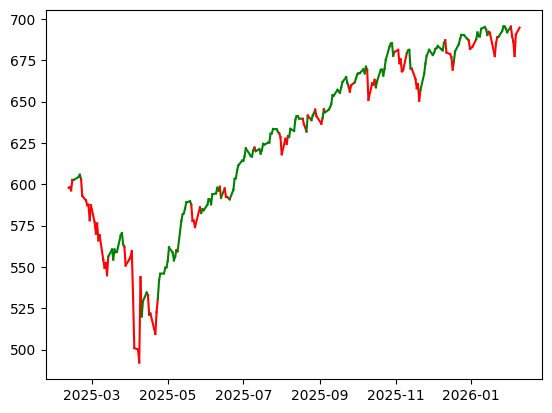

In [101]:
for i in range(1, len(df)):
  c = "g" if df["trend"].iloc[i] > 0 else "r"
  plt.plot(
    df.index[i-1:i+1],
    df["Close"].iloc[i-1:i+1],
    color=c
  )

plt.show()